# Paged KV Memory

Models the KV cache as a fixed pool of blocks, each holding `BLOCK_SIZE`
token slots. A sequence's cache is scattered across non-contiguous blocks
and indexed by a per-sequence page table. Same idea as vLLM's PagedAttention.

Compares three allocation strategies on the same pool (4,096 blocks ×
16 slots = 65,536 token slots):

- **paged** — allocate blocks on demand
- **naive** — reserve `max_seq_len=2048` slots per sequence
- **fixed** — reserve a fixed 200-slot window; requests exceeding it are rejected

Then sweeps block size and measures the fragmentation vs page-table tradeoff.

Numbers come from `03_paged_memory/results.csv`, produced by
`03_paged_memory/benchmark.py`.

Reproduce:

    uv run 03_paged_memory/fragmentation.py
    uv run 03_paged_memory/benchmark.py

In [1]:
import pandas as pd

df = pd.read_csv("../03_paged_memory/results.csv")
df

,block_size,peak_seqs,peak_blocks,waste_slots,fragmentation_pct,page_table_bytes,total_overhead_bytes
0,4,290,16373,424,0.647407,65492.0,7880660.0
1,8,286,8120,985,1.516318,32480.0,18188000.0
2,16,284,4083,1940,2.969630,16332.0,35774412.0
3,32,272,2041,4070,6.231627,8164.0,75026404.0
4,64,257,1024,7571,11.552429,4096.0,139552768.0
5,128,230,512,13795,21.049500,2048.0,254271488.0


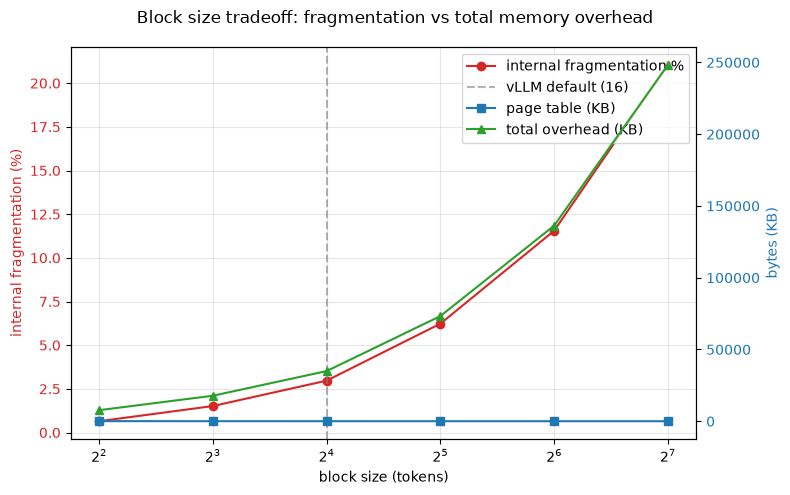

In [2]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))
xs = df["block_size"]

ax1.plot(xs, df["fragmentation_pct"], "o-", color="tab:red",
         label="internal fragmentation %")
ax1.set_xlabel("block size (tokens)")
ax1.set_ylabel("internal fragmentation (%)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.set_xscale("log", base=2)
ax1.grid(True, which="both", alpha=0.3)
ax1.axvline(16, color="gray", linestyle="--", alpha=0.6,
            label="vLLM default (16)")

ax2 = ax1.twinx()
ax2.plot(xs, df["page_table_bytes"] / 1024, "s-", color="tab:blue",
         label="page table (KB)")
ax2.plot(xs, df["total_overhead_bytes"] / 1024, "^-", color="tab:green",
         label="total overhead (KB)")
ax2.set_ylabel("bytes (KB)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.suptitle("Block size tradeoff: fragmentation vs total memory overhead")
fig.tight_layout()
plt.show()

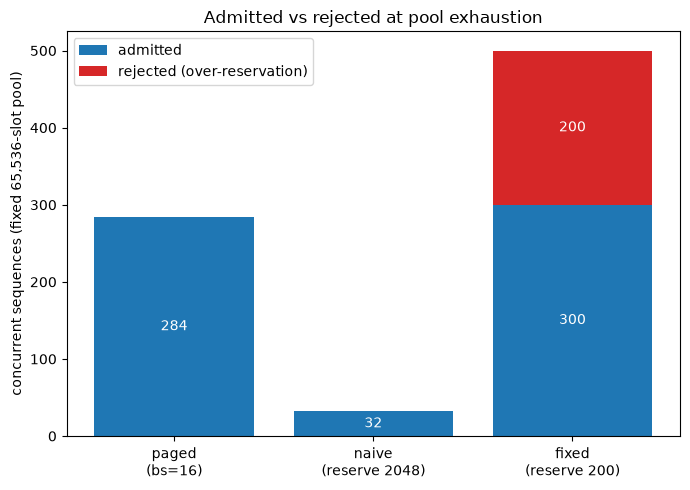

In [3]:
import matplotlib.pyplot as plt

strategies = ["paged\n(bs=16)", "naive\n(reserve 2048)", "fixed\n(reserve 200)"]
admitted   = [284, 32, 300]
rejected   = [0, 0, 200]

fig, ax = plt.subplots(figsize=(7, 5))
bars_adm = ax.bar(strategies, admitted, color="tab:blue", label="admitted")
bars_rej = ax.bar(strategies, rejected, bottom=admitted,
                  color="tab:red", label="rejected (over-reservation)")

for i, (a, r) in enumerate(zip(admitted, rejected)):
    ax.text(i, a / 2, str(a), ha="center", va="center", color="white")
    if r:
        ax.text(i, a + r / 2, str(r), ha="center", va="center", color="white")

ax.set_ylabel("concurrent sequences (fixed 65,536-slot pool)")
ax.set_title("Admitted vs rejected at pool exhaustion")
ax.legend()
plt.tight_layout()
plt.show()

## What this shows

**Paging beats pre-allocation by ~9× on concurrency, same memory.**
284 concurrent sequences admitted by paged allocation vs 32 by naive
`max_seq_len` reservation. Naive wastes 89% of the pool; paged wastes 3%.

**Block size trades fragmentation against page-table overhead.**
Smaller blocks waste fewer slots per sequence (bounded by `BLOCK_SIZE - 1`)
but require more page-table entries. In this memory-only model, the
optimum is the smallest block (bs=4).

**Real engines use bs=16 for a reason the model doesn't capture.**
Small blocks mean more memory gathers per attention step, which reduces
GPU memory throughput. The PagedAttention kernel amortizes per-block
overhead better at bs=16. The memory-optimal block size is a lower bound;
the realized choice is set by kernel behavior — which is what Milestone 4
measures on real hardware.

Full writeup: `README.md` § "Paged KV memory".